# 📝 User Story Generator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/user-story-gen/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/user-story-gen/demo.ipynb)

**Pain point:** *"Writing good user stories takes practice."*

Paste raw feature ideas and get back INVEST-scored user stories with Given/When/Then acceptance criteria — no API keys needed, runs fully offline.

**What this notebook covers:**
1. The core engine — parsing ideas, detecting feature type, templating acceptance criteria
2. Generating a backlog from six messy real-world feature ideas
3. INVEST scoring — how each story is graded and what to fix
4. Visualizing backlog quality
5. Try your own ideas


## Step 1 — The core engine

Three moves turn a raw idea into a proper user story:

1. **Parse** — if the idea is already in `As a X, I want Y, so that Z` form, split it apart; otherwise strip filler ("users should be able to…") and keep the capability.
2. **Detect feature type** — keyword rules classify the idea as `auth`, `search`, `crud`, `notification`, `report`, `upload`, `integration`, or `general`. The type picks the persona default, the benefit default, and the acceptance-criteria template.
3. **Score against INVEST** — six checks (Independent, Negotiable, Valuable, Estimable, Small, Testable), each worth ~17 points, each failure producing a concrete improvement suggestion.


In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

# --- Feature type detection -------------------------------------------------

FEATURE_KEYWORDS: Dict[str, List[str]] = {
    "auth": ["log in", "login", "sign up", "signup", "password", "sso", "register", "2fa", "authenticate"],
    "search": ["search", "filter", "find", "look up", "sort", "browse"],
    "notification": ["notify", "notification", "alert", "email me", "remind", "push", "digest"],
    "report": ["report", "dashboard", "export", "chart", "analytics", "download", "summary"],
    "upload": ["upload", "import", "attach", "drag and drop", "bulk load"],
    "integration": ["integrate", "sync", "webhook", "connect to", "api access", "slack", "salesforce"],
    "crud": ["create", "add", "edit", "update", "delete", "manage", "save", "archive"],
}

DEFAULT_PERSONA: Dict[str, str] = {
    "auth": "returning user",
    "search": "power user",
    "notification": "busy team member",
    "report": "team lead",
    "upload": "data owner",
    "integration": "ops engineer",
    "crud": "everyday user",
    "general": "user",
}

# --- Acceptance criteria templates (Given / When / Then) ---------------------

AC_TEMPLATES: Dict[str, List[str]] = {
    "auth": [
        "Given valid credentials, when the user submits the form, then they land on their home screen within 2 seconds",
        "Given invalid credentials, when the user submits the form, then a clear error shows without revealing which field was wrong",
        "Given 5 failed attempts, when the user tries again, then the account is temporarily locked and a reset path is offered",
    ],
    "search": [
        "Given a matching term, when the user searches, then results appear ranked by relevance within 1 second",
        "Given no matches, when the user searches, then an empty state suggests alternative terms",
        "Given active filters, when the user refines the query, then filters persist and the result count updates",
    ],
    "notification": [
        "Given the trigger event occurs, when conditions are met, then the notification is delivered within 1 minute",
        "Given notifications are muted, when the trigger fires, then nothing is sent and the event is still logged",
        "Given a notification is received, when the user clicks it, then they deep-link to the relevant item",
    ],
    "report": [
        "Given data exists for the selected range, when the user opens the report, then totals match the source system",
        "Given the report is on screen, when the user exports it, then the file downloads in the chosen format with all visible rows",
        "Given no data for the range, when the report loads, then an empty state explains why and suggests a wider range",
    ],
    "upload": [
        "Given a valid file, when the user uploads it, then a success message confirms rows/items processed",
        "Given an invalid or oversized file, when the user uploads it, then a specific validation error names the problem",
        "Given a slow connection, when the upload is in progress, then a progress indicator shows and cancel is available",
    ],
    "integration": [
        "Given valid credentials for the external system, when the user connects, then a test call confirms the link",
        "Given the connection drops, when a sync runs, then the failure is retried and surfaced in a status log",
        "Given a successful sync, when the user checks either system, then records match on both sides",
    ],
    "crud": [
        "Given valid input, when the user saves, then the item appears in the list immediately",
        "Given required fields are missing, when the user saves, then inline errors mark each missing field",
        "Given a delete action, when the user confirms, then the item is removed and an undo option is offered briefly",
    ],
    "general": [
        "Given the feature is available, when the user performs the main action, then the expected outcome is visible",
        "Given invalid input or state, when the user tries the action, then a clear error explains what to fix",
        "Given the action succeeds, when the user returns later, then the result has persisted",
    ],
}

DEFAULT_BENEFIT: Dict[str, str] = {
    "auth": "I can access my account securely without friction",
    "search": "I can find what I need without scanning everything manually",
    "notification": "I never miss something that needs my attention",
    "report": "I can make decisions from numbers instead of gut feel",
    "upload": "I can get my data in without manual re-entry",
    "integration": "my tools stay in sync without copy-paste",
    "crud": "I can keep my information accurate and up to date",
    "general": "I can get my job done faster",
}

VAGUE_WORDS = ["fast", "easy", "better", "user-friendly", "intuitive", "nice", "modern", "seamless", "simple"]
IMPLEMENTATION_WORDS = ["button", "dropdown", "database", "endpoint", "modal", "postgres", "react", "table schema"]
SCOPE_WORDS = ["all ", "everything", "entire", "every ", "any kind"]


@dataclass
class UserStory:
    raw: str
    persona: str
    capability: str
    benefit: str
    feature_type: str
    acceptance_criteria: List[str] = field(default_factory=list)
    invest_score: int = 0
    invest_flags: List[str] = field(default_factory=list)

    @property
    def story(self) -> str:
        return f"As a {self.persona}, I want to {self.capability}, so that {self.benefit}."


def detect_feature_type(text: str) -> str:
    lowered = text.lower()
    for ftype, keywords in FEATURE_KEYWORDS.items():
        if any(kw in lowered for kw in keywords):
            return ftype
    return "general"


def parse_idea(text: str) -> Tuple[Optional[str], str, Optional[str]]:
    """Split a raw idea into (persona, capability, benefit). Persona/benefit may be absent."""
    match = re.match(
        r"as an? (?P<persona>[^,]+),?\s*i want (?:to )?(?P<cap>.+?)(?:,?\s*so that (?P<benefit>.+))?$",
        text.strip().rstrip("."),
        re.IGNORECASE,
    )
    if match:
        return match.group("persona").strip(), match.group("cap").strip(), (
            match.group("benefit").strip() if match.group("benefit") else None
        )
    capability = re.sub(r"^(i want to|we need to|add|build|implement|users? should be able to)\s+", "",
                        text.strip().rstrip("."), flags=re.IGNORECASE)
    return None, capability.strip(), None


def score_invest(story: UserStory) -> Tuple[int, List[str]]:
    """Score a story against INVEST. Each of 6 checks worth up to ~17 points."""
    flags: List[str] = []
    lowered = story.capability.lower()
    score = 0

    if " and " not in lowered and ";" not in lowered:
        score += 17
    else:
        flags.append("Independent: capability bundles multiple things — split at the 'and'")

    if not any(w in lowered for w in IMPLEMENTATION_WORDS):
        score += 17
    else:
        flags.append("Negotiable: describes the implementation, not the need — state the outcome instead")

    if story.benefit and story.benefit not in DEFAULT_BENEFIT.values():
        score += 17
    else:
        flags.append("Valuable: no explicit benefit given — add a real 'so that' (a default was used)")

    if story.feature_type != "general" and len(lowered.split()) >= 3:
        score += 17
    else:
        flags.append("Estimable: too vague to size — name the concrete capability")

    if len(lowered.split()) <= 14 and not any(w in lowered for w in SCOPE_WORDS):
        score += 16
    else:
        flags.append("Small: scope sounds big — carve out the thinnest useful slice")

    if not any(w in lowered for w in VAGUE_WORDS):
        score += 16
    else:
        flags.append("Testable: vague quality words ('easy', 'fast') — replace with a measurable check")

    return score, flags


def _normalize_capability(capability: str) -> str:
    cap = capability[0].lower() + capability[1:] if capability else capability
    cap = re.sub(r"\btheir\b", "my", cap)
    cap = re.sub(r"\bthem\b", "me", cap)
    return re.sub(r"^to\s+", "", cap)


def generate_story(idea: str, persona: str = "") -> UserStory:
    parsed_persona, capability, parsed_benefit = parse_idea(idea)
    capability = _normalize_capability(capability)
    ftype = detect_feature_type(idea)
    final_persona = persona.strip() or parsed_persona or DEFAULT_PERSONA[ftype]
    benefit = parsed_benefit or DEFAULT_BENEFIT[ftype]
    story = UserStory(
        raw=idea.strip(),
        persona=final_persona,
        capability=capability,
        benefit=benefit,
        feature_type=ftype,
        acceptance_criteria=list(AC_TEMPLATES[ftype]),
    )
    story.invest_score, story.invest_flags = score_invest(story)
    return story


def generate_backlog(ideas_text: str, persona: str = "") -> List[UserStory]:
    lines = [ln.strip("-• \t") for ln in ideas_text.strip().splitlines() if ln.strip()]
    return [generate_story(line, persona) for line in lines]


def backlog_to_markdown(stories: List[UserStory]) -> str:
    parts: List[str] = ["# Generated User Stories\n"]
    for i, s in enumerate(stories, 1):
        parts.append(f"## Story {i}: {s.capability.capitalize()}")
        parts.append(f"**{s.story}**  \n*Type: {s.feature_type} · INVEST score: {s.invest_score}/100*\n")
        parts.append("**Acceptance criteria:**")
        parts.extend(f"- {ac}" for ac in s.acceptance_criteria)
        if s.invest_flags:
            parts.append("\n**Improve this story:**")
            parts.extend(f"- {f}" for f in s.invest_flags)
        parts.append("")
    return "\n".join(parts)


## Step 2 — Generate a backlog from messy ideas

Six ideas exactly as they show up in real intake channels: some half-formed, one already well-written, one hopelessly vague.

In [2]:
ideas = """Users should be able to reset their password by email
Search projects by tag and owner
As a team lead, I want to export the sprint report to PDF, so that I can share it with stakeholders
Make the app easy and fast for everyone
Upload a CSV of customers and validate it
Notify me when a deployment fails"""

stories = generate_backlog(ideas)
for i, s in enumerate(stories, 1):
    print(f"Story {i} [{s.feature_type}] — INVEST {s.invest_score}/100")
    print(f"  {s.story}")
    print()

Story 1 [auth] — INVEST 83/100
  As a returning user, I want to reset my password by email, so that I can access my account securely without friction.

Story 2 [search] — INVEST 66/100
  As a power user, I want to search projects by tag and owner, so that I can find what I need without scanning everything manually.

Story 3 [report] — INVEST 100/100
  As a team lead, I want to export the sprint report to PDF, so that I can share it with stakeholders.

Story 4 [general] — INVEST 33/100
  As a user, I want to make the app easy and fast for everyone, so that I can get my job done faster.

Story 5 [upload] — INVEST 66/100
  As a data owner, I want to upload a CSV of customers and validate it, so that I can get my data in without manual re-entry.

Story 6 [notification] — INVEST 83/100
  As a busy team member, I want to notify me when a deployment fails, so that I never miss something that needs my attention.



## Step 3 — Acceptance criteria

Every story gets 3 Given/When/Then criteria from its feature-type template — including the unhappy path (invalid input, failure, empty state), which is what most hand-written stories forget.

In [3]:
s = stories[0]  # the password-reset story
print(s.story)
print()
print("Acceptance criteria:")
for ac in s.acceptance_criteria:
    print(f"  • {ac}")

As a returning user, I want to reset my password by email, so that I can access my account securely without friction.

Acceptance criteria:
  • Given valid credentials, when the user submits the form, then they land on their home screen within 2 seconds
  • Given invalid credentials, when the user submits the form, then a clear error shows without revealing which field was wrong
  • Given 5 failed attempts, when the user tries again, then the account is temporarily locked and a reset path is offered


## Step 4 — INVEST flags: what to fix

Low scores come with specific, actionable flags. The vague idea ("make the app easy and fast") gets caught on four of the six checks.

In [4]:
for i, s in enumerate(stories, 1):
    if s.invest_flags:
        print(f"Story {i} ({s.invest_score}/100): {s.raw}")
        for flag in s.invest_flags:
            print(f"  ⚠ {flag}")
        print()

Story 1 (83/100): Users should be able to reset their password by email
  ⚠ Valuable: no explicit benefit given — add a real 'so that' (a default was used)

Story 2 (66/100): Search projects by tag and owner
  ⚠ Independent: capability bundles multiple things — split at the 'and'
  ⚠ Valuable: no explicit benefit given — add a real 'so that' (a default was used)

Story 4 (33/100): Make the app easy and fast for everyone
  ⚠ Independent: capability bundles multiple things — split at the 'and'
  ⚠ Valuable: no explicit benefit given — add a real 'so that' (a default was used)
  ⚠ Estimable: too vague to size — name the concrete capability
  ⚠ Testable: vague quality words ('easy', 'fast') — replace with a measurable check

Story 5 (66/100): Upload a CSV of customers and validate it
  ⚠ Independent: capability bundles multiple things — split at the 'and'
  ⚠ Valuable: no explicit benefit given — add a real 'so that' (a default was used)

Story 6 (83/100): Notify me when a deployment fails

## Step 5 — Visualize backlog quality

One glance shows which stories are sprint-ready (green, ≥80), which need a tweak (amber), and which need a rewrite (red).

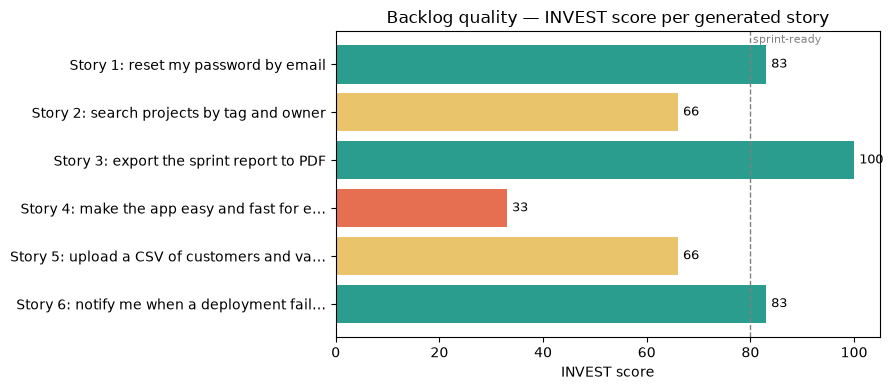

In [5]:
import matplotlib.pyplot as plt

labels = [f"Story {i+1}: {s.capability[:32]}…" if len(s.capability) > 32 else f"Story {i+1}: {s.capability}"
          for i, s in enumerate(stories)]
scores = [s.invest_score for s in stories]
colors = ["#2a9d8f" if v >= 80 else "#e9c46a" if v >= 60 else "#e76f51" for v in scores]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels, scores, color=colors)
ax.set_xlim(0, 105)
ax.set_xlabel("INVEST score")
ax.set_title("Backlog quality — INVEST score per generated story")
ax.axvline(80, color="gray", linestyle="--", linewidth=1)
ax.text(80.5, -0.45, "sprint-ready", fontsize=8, color="gray")
ax.invert_yaxis()
for bar, v in zip(bars, scores):
    ax.text(v + 1, bar.get_y() + bar.get_height() / 2, str(v), va="center", fontsize=9)
fig.tight_layout()
fig.savefig("invest_scores.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Idea quality | Result |
|---|---|
| Already well-formed ("As a team lead…") | Parsed as-is, scored **100/100** |
| Decent one-liner ("reset their password") | Story + persona + benefit filled in, **83/100**, flagged to add a real benefit |
| Bundled scope ("by tag **and** owner") | Flagged **Independent** — split at the "and" |
| Vague wish ("easy and fast for everyone") | **33/100** — flagged on Independent, Valuable, Estimable, Testable |

The generator doesn't replace product judgment — it gives every raw idea the same disciplined first pass, and tells you exactly what to sharpen.


## Try your own

Uncomment and edit:

In [6]:
# my_ideas = """
# Let admins deactivate a user account
# Sync invoices to QuickBooks
# Dashboard should feel snappier
# """
# for s in generate_backlog(my_ideas, persona="admin"):
#     print(f"[{s.invest_score}/100] {s.story}")
#     for ac in s.acceptance_criteria:
#         print(f"   • {ac}")
#     for flag in s.invest_flags:
#         print(f"   ⚠ {flag}")
#     print()

---

Part of **[Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder)** — 60 mini AI products in 6 months.

Prefer a UI? Run the Streamlit version:

```bash
pip install -r requirements.txt
streamlit run app.py
```
